In [1]:
import os
import numpy as np
import joblib
import matplotlib.pyplot as plt

# eps_model_path = '/Users/nishchal_mac/Desktop/FDTD_Bio/src/training_data_models/rf_eps_model.pkl'
# sig_model_path = '/Users/nishchal_mac/Desktop/FDTD_Bio/src/training_data_models/rf_sigma_model.pkl'
# reg_eps = joblib.load(eps_model_path)
# reg_sig = joblib.load(sig_model_path)

In [2]:
from typing import Tuple
import numpy as np
from scipy.io import loadmat


def load_data(data_dir: str) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Load all .mat files from the given directory, extract Ez_refl, epsilon_r, and sigma,
    and stack them into 3D arrays.

    Args:
        data_dir: Path to the directory containing .mat files.

    Returns:
        A tuple of three numpy arrays:
            - X_array: stacked Ez_refl with shape (N, H, W)
            - y_eps_array: stacked epsilon_r with shape (N, H, W)
            - y_sig_array: stacked sigma with shape (N, H, W)
    """
    # find all files ending with '.mat'
    mat_files = [
        os.path.join(data_dir, fname)
        for fname in os.listdir(data_dir)
        if fname.endswith('.mat')
    ]

    X_list = []
    eps_list = []
    sig_list = []

    for matfile in mat_files:
        mat = loadmat(matfile, squeeze_me=True, struct_as_record=False)
        X_list.append(mat.get('Ez_refl'))
        eps_list.append(mat.get('epsilon_r'))
        sig_list.append(mat.get('sigma'))

    # Stack into 3D arrays of shape (N, H, W)
    X_array = np.stack(X_list, axis=0)
    y_eps_array = np.stack(eps_list, axis=0)
    y_sig_array = np.stack(sig_list, axis=0)
    print("X_array   shape:", X_array.shape)
    print("y_eps_array shape:", y_eps_array.shape)
    print("y_sig_array shape:", y_sig_array.shape) 

    return X_array, y_eps_array, y_sig_array


In [12]:
# loader/detection_loader.py

import numpy as np
from skimage import measure

def load_maps_and_boxes(eps_array: np.ndarray,
                        sig_array: np.ndarray,
                        sigma_thresh: float) -> (np.ndarray, list):
    """
    eps_array:  (N, H1, W1)  predicted permittivity
    sig_array:  (N, H1, W1)  predicted conductivity
    returns:
      images:   (N, 2, H1, W1)  — channels = [epsilon, sigma]
      targets:  list of dicts { boxes: (Ki×4), labels: (Ki,) }
    """

    N, H1, W1 = eps_array.shape
    images = np.stack([eps_array, sig_array], axis=1).astype(np.float32)

    targets = []
    for i in range(N):
        mask = (sig_array[i] == sigma_thresh)
        props = measure.regionprops(measure.label(mask))
        if not props:
            boxes = np.zeros((0,4), dtype=np.float32)
            labels = np.zeros((0,),   dtype=np.int64)
        else:
            # one box around the largest metal blob
            minr, minc, maxr, maxc = max(props, key=lambda p: p.area).bbox
            boxes  = np.array([[minc, minr, maxc, maxr]], dtype=np.float32)
            labels = np.array([1], dtype=np.int64)

        targets.append({"boxes": boxes, "labels": labels})

    return images, targets


In [3]:
from sklearn.model_selection import train_test_split
train_dir='/Users/nishchal_mac/Desktop/FDTD_Bio/Chest_Data'
X_array, y_eps_array, y_sig_array = load_data(train_dir)
X_train, X_test, y_eps_train, y_eps_test, y_sig_train, y_sig_test = train_test_split(
        X_array, y_eps_array, y_sig_array,
        test_size=0.2,
        random_state=42,
        shuffle=True
    )


X_array   shape: (1271, 5, 864)
y_eps_array shape: (1271, 100, 100)
y_sig_array shape: (1271, 100, 100)


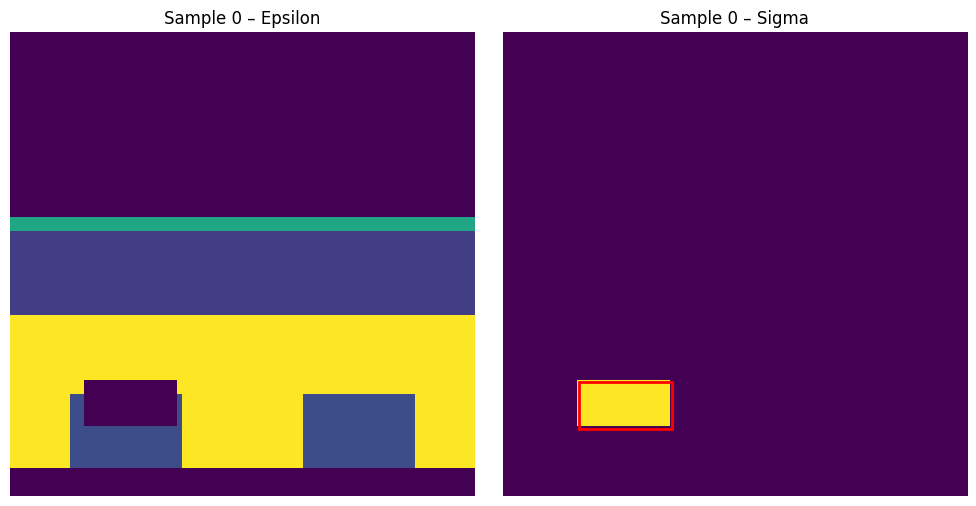

In [35]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

def plot_sample(image: np.ndarray, target: dict, idx: int = 0):
    """
    Plot the epsilon and sigma channels side by side,
    overlaying any detected box on the sigma plot.

    Args:
        image:  np.ndarray of shape (2, H1, W1), channels = [epsilon, sigma]
        target: dict with keys 'boxes' (K×4 array) and 'labels' (K,)
        idx:     sample index (for titles)
    """
    eps_ch, sig_ch = image[0], image[1]
    boxes = target["boxes"]

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(eps_ch, cmap='viridis')
    axes[0].set_title(f'Sample {idx} – Epsilon')
    axes[0].axis('off')

    axes[1].imshow(sig_ch, cmap='viridis')
    axes[1].set_title(f'Sample {idx} – Sigma')
    axes[1].axis('off')

    # Overlay each box on the sigma channel
    for (x1, y1, x2, y2) in boxes:
        width, height = x2 - x1, y2 - y1
        rect = Rectangle(
            (x1, y1), width, height,
            edgecolor='red', facecolor='none', linewidth=2
        )
        axes[1].add_patch(rect)

    plt.tight_layout()
    plt.show()


# --- Usage example ---
# assuming you have eps_array, sig_array and sigma_thresh defined:
images, targets = load_maps_and_boxes(y_eps_array, y_sig_array, 1e5)

# Plot the very first sample
plot_sample(images[1], targets[1], idx=0)


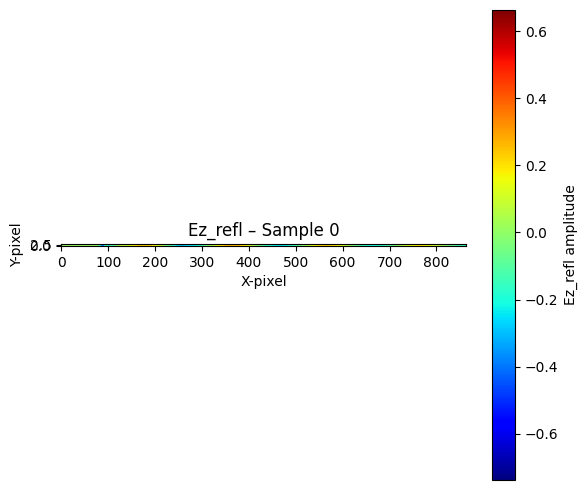

/var/folders/cw/4m37hl1j33ggv48mmy6vc8fm0000gn/T/ipykernel_1455/3033060774.py:23: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


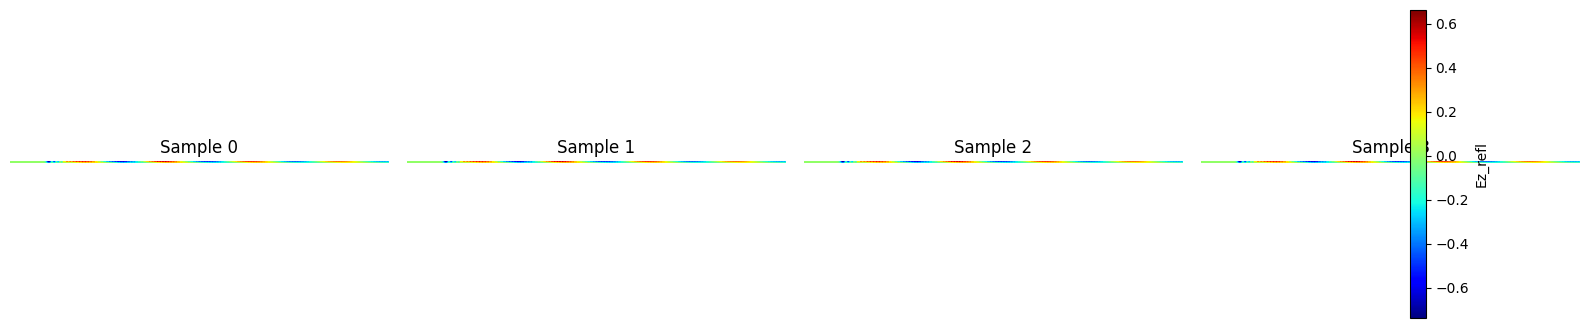

In [4]:
import matplotlib.pyplot as plt

# 1) Plot just the very first sample
plt.figure(figsize=(6,5))
plt.imshow(X_array[0], cmap='jet', origin='lower')
plt.colorbar(label='Ez_refl amplitude')
plt.title('Ez_refl – Sample 0')
plt.xlabel('X-pixel')
plt.ylabel('Y-pixel')
plt.tight_layout()
plt.show()


# 2) Plot a 1×4 grid of the first four samples
n_samples = min(4, X_array.shape[0])
fig, axes = plt.subplots(1, n_samples, figsize=(4*n_samples,4))
for i in range(n_samples):
    ax = axes[i]
    im = ax.imshow(X_array[i], cmap='jet', origin='lower')
    ax.set_title(f'Sample {i}')
    ax.axis('off')
fig.colorbar(im, ax=axes, fraction=0.02, pad=0.04, label='Ez_refl')
plt.tight_layout()
plt.show()


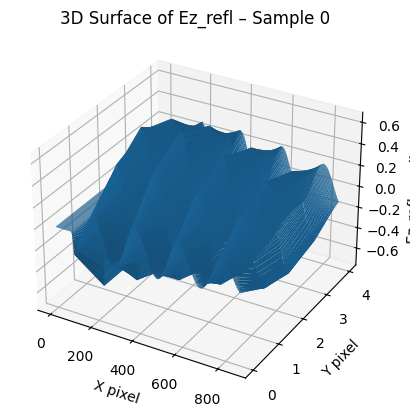

In [5]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# Pick the sample you want to visualize (here: the very first one)
Z = X_array[0]   # shape (H, W)
H, W = Z.shape

# Create grid of X/Y coordinates
X, Y = np.meshgrid(np.arange(W), np.arange(H))

# Plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, rstride=1, cstride=1, linewidth=0, antialiased=True)

# Labels
ax.set_xlabel('X pixel')
ax.set_ylabel('Y pixel')
ax.set_zlabel('Ez_refl amplitude')
ax.set_title('3D Surface of Ez_refl – Sample 0')

plt.show()


In [9]:
import numpy as np
from sklearn.decomposition import PCA

# 1) Compute variance per column
col_var = np.var(X_array, axis=(0,1))   # shape (W,)

# 2) Pick the top-10 most “active” columns
k = 10
top_k_idx = np.argsort(col_var)[-k:]

# 3) Extract those columns
X_reduced = X_array[:, :, top_k_idx]    # shape (N, H, k)

# 4) Flatten and (optionally) PCA
N, H, _ = X_reduced.shape
X_feat = X_reduced.reshape(N, H * k)    # shape (N, H*k)
pca = PCA(n_components=5)
X_pca = pca.fit_transform(X_feat)       # shape (N, 5)


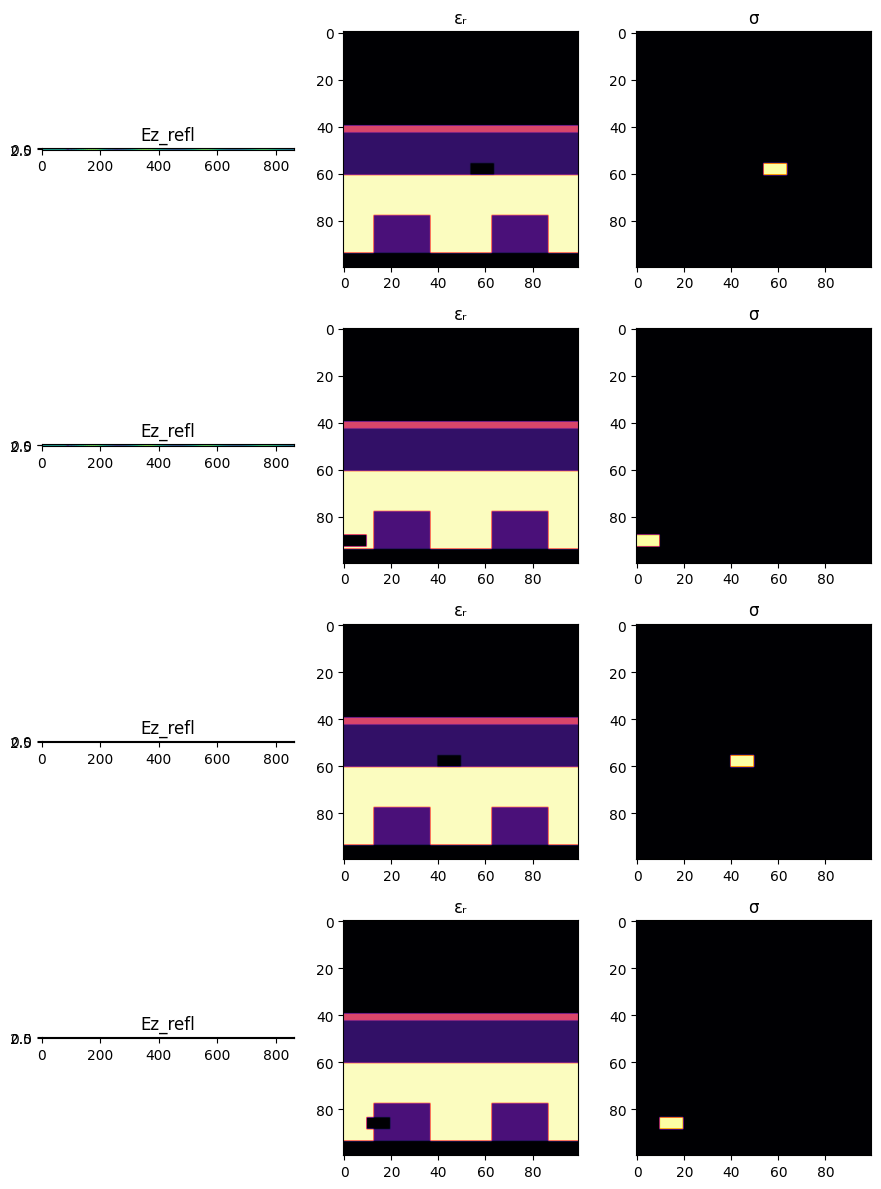

In [5]:
import matplotlib.pyplot as plt

n_show = 4
fig, axes = plt.subplots(n_show, 3, figsize=(9,3*n_show))
for k in range(n_show):
    axes[k,0].imshow(X_array[k], cmap="viridis")
    axes[k,0].set_title("Ez_refl")
    axes[k,1].imshow(y_eps_array[k], cmap="magma")
    axes[k,1].set_title("εᵣ")
    axes[k,2].imshow(y_sig_array[k], cmap="inferno")
    axes[k,2].set_title("σ")
plt.tight_layout()
plt.show()


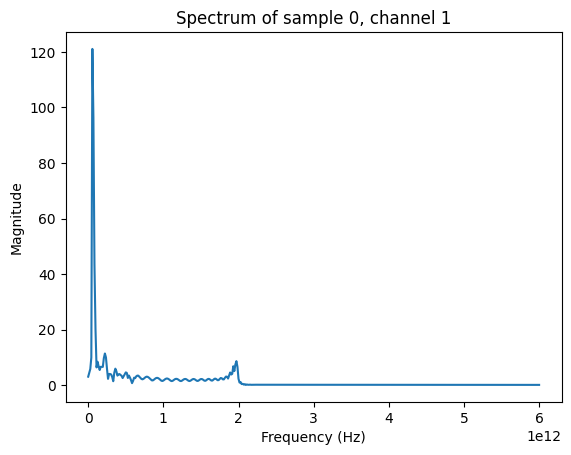

In [28]:
c    = 3e8            # m/s
f0   = 60e9           # Hz
λ    = c / f0         # 5 mm
Δx   = λ / 10         # 0.5 mm
dt   = Δx / (20 * c)  # CFL → 8.3333e-14 s

Xf    = np.fft.rfft(X_array, axis=2)                     # (N, M, P//2+1)
freqs = np.fft.rfftfreq(X_array.shape[2], d=dt)          # (P//2+1,)

# plot sample 0, channel 0
i, m = 0, 1
plt.figure()
plt.plot(freqs, np.abs(Xf[i, m]))
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title(f"Spectrum of sample {i}, channel {m}")
plt.show()

In [18]:
import numpy as np

def fft_spectral_features(X, dt, f_low=0, f_high=None):
    """
    X:      (N, M, P) real time‐series
    dt:     time-step (s)
    f_low:  lowest freq to consider (Hz)
    f_high: highest freq (Hz), or None=Nyquist
    returns (N, M*5) array of features
    """
    N, M, P = X.shape
    # 1) FFT and freqs
    Xf    = np.fft.rfft(X, axis=2)             # (N, M, P//2+1), complex
    freqs = np.fft.rfftfreq(P, d=dt)           # (P//2+1,)
    
    # 2) band mask
    if f_high is None:
        mask = freqs >= f_low
    else:
        mask = (freqs >= f_low) & (freqs <= f_high)
    fband = freqs[mask]
    
    # 3) loop & extract
    feats = np.zeros((N, M*5))
    for i in range(N):
        vec = []
        for m in range(M):
            mag = np.abs(Xf[i, m, mask])        # spectrum magnitudes in band
            # a) peak
            idx_peak = np.argmax(mag)
            f_peak   = fband[idx_peak]
            mag_peak = mag[idx_peak]
            # b) energy in band
            energy   = np.sum(mag**2)
            # c) centroid
            centroid = (mag * fband).sum() / mag.sum()
            # d) bandwidth (2nd moment)
            bw = np.sqrt(((fband - centroid)**2 * mag).sum() / mag.sum())
            vec += [f_peak, mag_peak, energy, centroid, bw]
        feats[i, :] = vec
    return feats


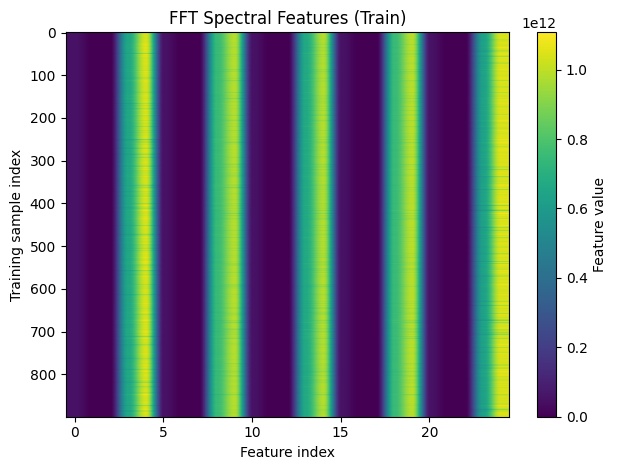

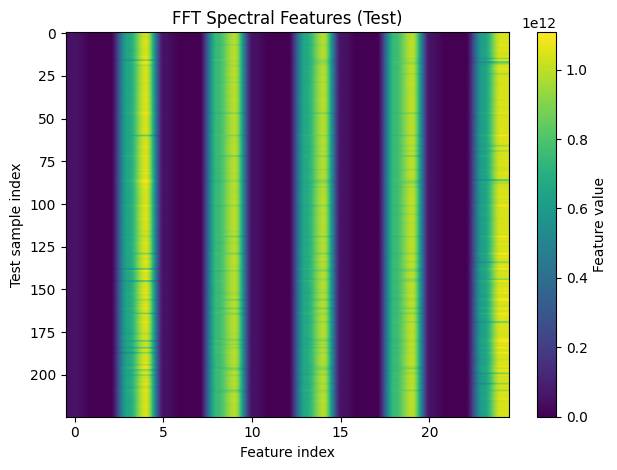

In [21]:
Xf_tr = fft_spectral_features(X_train, dt)
Xf_te = fft_spectral_features(X_test, dt)
# 1) Train heatmap
plt.figure()
plt.imshow(Xf_tr, aspect='auto')
plt.xlabel('Feature index')
plt.ylabel('Training sample index')
plt.title('FFT Spectral Features (Train)')
plt.colorbar(label='Feature value')
plt.tight_layout()
plt.show()

# 2) Test heatmap
plt.figure()
plt.imshow(Xf_te, aspect='auto')
plt.xlabel('Feature index')
plt.ylabel('Test sample index')
plt.title('FFT Spectral Features (Test)')
plt.colorbar(label='Feature value')
plt.tight_layout()
plt.show()

In [8]:
    # 2) Add channel dims: (N,H,W) → (N,H,W,1)
Xtr = X_train[..., np.newaxis]
Xte = X_test[...,  np.newaxis]
eps_tr = y_eps_train[..., np.newaxis]
eps_te = y_eps_test[...,  np.newaxis]
sig_tr = y_sig_train[..., np.newaxis]
sig_te = y_sig_test[...,  np.newaxis]

H, W, _ = Xtr.shape[1:]
print(Xtr.shape[1:])

(5, 864, 1)


In [24]:
from scipy.io import loadmat
train_dir = os.path.join(os.path.dirname(eps_model_path), 'train_data')
Xtr_img      = np.load(os.path.join(train_dir, 'Xtr_img.npy'))
Xte_img      = np.load(os.path.join(train_dir, 'Xte_img.npy'))
y_eps_tr_img = np.load(os.path.join(train_dir, 'y_eps_tr_img.npy'))
y_eps_te_img = np.load(os.path.join(train_dir, 'y_eps_te_img.npy'))
y_sig_tr_img = np.load(os.path.join(train_dir, 'y_sig_tr_img.npy'))
y_sig_te_img = np.load(os.path.join(train_dir, 'y_sig_te_img.npy'))
y_eps_train = np.load(os.path.join(train_dir, 'y_eps_train.npy'))

sample_path = '/Users/nishchal_mac/Desktop/FDTD_Bio/data/FDTD_case_0012_mx40_my12.mat'
mat = loadmat(sample_path, squeeze_me=True, struct_as_record=False)
Ez = mat.get('Ez_refl')
if Ez is None:
    raise ValueError(f"Ez_refl not found in {sample_path}")
_,      H, W = y_eps_train.shape
X_new = Ez.reshape(1, -1)

# Predict epsilon_r and sigma maps
eps_flat = reg_eps.predict(X_new)
sig_flat = reg_sig.predict(X_new)
eps_map = eps_flat.reshape(H, W)
sig_map = sig_flat.reshape(H, W)

[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  25 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  25 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished


In [25]:
eps_val      = 1.0
eps_tol      = 0.1
sig_thresh   = 1e5
metal_mask_flat = ((sig_flat > sig_thresh) &
                   np.isclose(eps_flat, eps_val, atol=eps_tol))
metal_mask = metal_mask_flat.reshape(H, W)

# 5) Get pixel coordinates (row, col) of metal
coords = np.argwhere(metal_mask)
print(f"Found {len(coords)} metal pixels.")


Found 187 metal pixels.


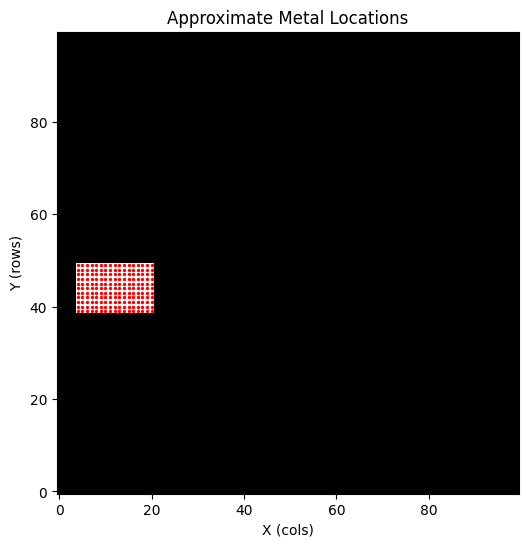

In [26]:
# 6) Visualize
plt.figure(figsize=(6,6))
plt.imshow(metal_mask, cmap='gray', origin='lower')
# scatter needs (x=cols, y=rows)
plt.scatter(coords[:,1], coords[:,0], s=2, c='red')
plt.title('Approximate Metal Locations')
plt.xlabel('X (cols)')
plt.ylabel('Y (rows)')
plt.show()

In [27]:
import numpy as np
from skimage.measure import label, regionprops
import matplotlib.pyplot as plt

# assuming you already have metal_mask of shape (H,W), boolean
# metal_mask = ...

# 1) Total area in pixels
total_pixels = metal_mask.sum()
print(f"Total metal area: {total_pixels} pixels")

# 2) Label connected regions and extract stats
labeled = label(metal_mask, connectivity=2)   # 8-connectivity
props = regionprops(labeled)

for i, prop in enumerate(props, 1):
    area_px = prop.area
    eq_diam_px = prop.equivalent_diameter
    minr, minc, maxr, maxc = prop.bbox
    width_px  = maxc - minc
    height_px = maxr - minr

    print(f"\nBlob {i}:")
    print(f"  • Area:                {area_px} px")
    print(f"  • Equivalent diameter: {eq_diam_px:.1f} px")
    print(f"  • Bounding box size:   {width_px}×{height_px} px")


Total metal area: 187 pixels

Blob 1:
  • Area:                187.0 px
  • Equivalent diameter: 15.4 px
  • Bounding box size:   17×11 px


Total skin area: 300 pixels
Found 300 skin pixels.

Skin blob 1:
  • Area:                300.0 px
  • Equivalent diameter: 19.5 px
  • Bounding box size:   100×3 px
  • Centroid:            (51.0, 49.5) px


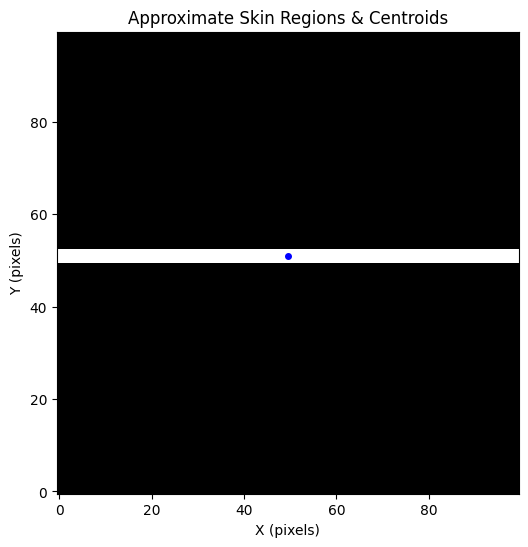

In [29]:
# 1) Define skin thresholds
eps_skin_val   = 7.9753
sig_skin_val   = 36.397
eps_skin_tol   = 0.1    # adjust if you need tighter/looser matching
sig_skin_tol   = 0.5    # ditto

# 2) Build binary mask for skin
skin_mask_flat = (
    np.isclose(eps_flat, eps_skin_val, atol=eps_skin_tol) &
    np.isclose(sig_flat, sig_skin_val, atol=sig_skin_tol)
)
skin_mask = skin_mask_flat.reshape(H, W)

# 3) Get all skin‐pixels and overall area
skin_pixels   = skin_mask.sum()
skin_coords   = np.argwhere(skin_mask)
print(f"Total skin area: {skin_pixels} pixels")
print(f"Found {len(skin_coords)} skin pixels.")

# 4) Label connected skin‐regions and extract per‐blob stats
labeled_skin = label(skin_mask, connectivity=2)
skin_props   = regionprops(labeled_skin)

for i, prop in enumerate(skin_props, 1):
    area_px      = prop.area
    eq_diam_px   = prop.equivalent_diameter
    minr, minc, maxr, maxc = prop.bbox
    width_px     = maxc - minc
    height_px    = maxr - minr

    print(f"\nSkin blob {i}:")
    print(f"  • Area:                {area_px} px")
    print(f"  • Equivalent diameter: {eq_diam_px:.1f} px")
    print(f"  • Bounding box size:   {width_px}×{height_px} px")
    print(f"  • Centroid:            ({prop.centroid[0]:.1f}, {prop.centroid[1]:.1f}) px")
    
# 5) Visualize skin mask + centroids
fig, ax = plt.subplots(figsize=(6,6))
ax.imshow(skin_mask, cmap='gray', origin='lower')
for prop in skin_props:
    y0, x0 = prop.centroid
    ax.plot(x0, y0, 'bo', markersize=4)
ax.set_title('Approximate Skin Regions & Centroids')
ax.set_xlabel('X (pixels)')
ax.set_ylabel('Y (pixels)')
plt.show()


In [35]:
from scipy.ndimage import distance_transform_edt
# 1) Label connected components
labeled_metal = label(metal_mask, connectivity=2)
labeled_skin  = label(skin_mask,  connectivity=2)

# 2) Extract region properties
metal_props = regionprops(labeled_metal)
skin_props  = regionprops(labeled_skin)

# 3) List all centroids (row, col) in pixels
metal_centroids = [prop.centroid for prop in metal_props]
skin_centroids  = [prop.centroid  for prop in skin_props]

# 4) Pick the largest‐area blob as representative
metal_centroid = max(metal_props, key=lambda p: p.area).centroid
skin_centroid  = max(skin_props,  key=lambda p: p.area).centroid
delt_x=0.0005
row_s, col_s = skin_centroid
row_m, col_m = metal_centroid

# 1) Differences in each axis (in pixels)
Δr = row_s - row_m
Δc = col_s - col_m

# 2) Euclidean distance in pixels
dist_px = np.sqrt(Δr**2 + Δc**2)


# 3) Convert to physical units
dist_phys = dist_px * delt_x
print(f"gap = {dist_phys:.4f} (m)")

gap = 0.0191 (m)


In [42]:
import numpy as np
from scipy.ndimage import distance_transform_edt
from skimage.segmentation import find_boundaries

# --- assume you already have: ---
#   metal_mask : bool array (H×W)
#   skin_mask  : bool array (H×W)
#   delt_x      : float (physical size per pixel)
# -------------------------------

# 1) Compute distance maps to each surface:
#    invert masks so edt gives distance _to_ the material
dist_to_skin  = distance_transform_edt(~skin_mask)
dist_to_metal = distance_transform_edt(~metal_mask)

# 2) Extract the boundary pixels:
metal_boundary = find_boundaries(metal_mask, mode='outer')  # True on metal edge
skin_boundary  = find_boundaries(skin_mask,  mode='outer')  # True on skin edge

# 3) For each boundary pixel, sample the other‐material’s distance map:
#    these are distances _from_ each surface to the other surface
d_metal2skin_px = dist_to_skin[metal_boundary]
d_skin2metal_px = dist_to_metal[skin_boundary]

# 4) Convert to physical units
d_metal2skin_phys = d_metal2skin_px * delt_x*100
d_skin2metal_phys = d_skin2metal_px * delt_x

# 5) Report some stats
print("Metal→Skin gap (phys):  min {:.4f}, avg {:.4f}, max {:.4f}".format(
    d_metal2skin_phys.min(), d_metal2skin_phys.mean(), d_metal2skin_phys.max()))


Metal→Skin gap (px):  min 0.00, avg 6.00, max 12.00
Metal→Skin gap (phys):  min 0.0000, avg 0.3000, max 0.6000
